# Parking Demand Modelling


In [20]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

In [21]:
# paths
current_dir = os.getcwd()
project_dir = os.path.dirname(current_dir)

processed_dir = os.path.join(project_dir, "data", "processed")
output_dir = os.path.join(current_dir, "outputs")
model_dir = os.path.join(output_dir, "model")
tables_dir = os.path.join(output_dir, "tables")
figures_dir = os.path.join(output_dir, "figures")

os.makedirs(model_dir, exist_ok=True)
os.makedirs(tables_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

demand_file = os.path.join(processed_dir, "cleaned_demand_data.csv")

print("Processed data folder:", processed_dir)
print("Model input file:", demand_file)

Processed data folder: c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\data\processed
Model input file: c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\data\processed\cleaned_demand_data.csv


In [22]:
# load processed demand data
df = pd.read_csv(demand_file)

print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (1575, 5)


,zone_number,status_day,status_hour,average_occupancy,demand_level
0,7010.0,Friday,1,0.0,Low
1,7010.0,Thursday,21,1.0,High
2,7010.0,Thursday,22,1.0,High
3,7010.0,Thursday,23,1.0,High
4,7010.0,Wednesday,9,0.0,Low


## Data checks

Before modelling, it is useful to confirm the expected columns exist and to remove rows that would break training.

In [23]:
required_columns = [
    "zone_number",
    "status_hour",
    "status_day",
    "is_weekend",
    "average_occupancy",
    "demand_level"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if "is_weekend" not in df.columns:
    weekend_days = ["Saturday", "Sunday"]
    df["is_weekend"] = df["status_day"].isin(weekend_days)

print("All required columns are available.")
print("\nColumn types:")
print(df.dtypes)
print("\nMissing values:")
print(df[required_columns].isnull().sum())

All required columns are available.

Column types:
zone_number          float64
status_day               str
status_hour            int64
average_occupancy    float64
demand_level             str
is_weekend              bool
dtype: object

Missing values:
zone_number          0
status_hour          0
status_day           0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


In [24]:
model_df = df[required_columns].copy()
model_df = model_df.dropna(subset=["zone_number", "status_hour", "status_day", "is_weekend", "demand_level"])

model_df["zone_number"] = pd.to_numeric(model_df["zone_number"], errors="coerce")
model_df["status_hour"] = pd.to_numeric(model_df["status_hour"], errors="coerce")
model_df["is_weekend"] = model_df["is_weekend"].astype(str)
model_df["status_day"] = model_df["status_day"].astype(str)
model_df["demand_level"] = model_df["demand_level"].astype(str)

model_df = model_df.dropna(subset=["zone_number", "status_hour"])

print("Cleaned modelling dataset shape:", model_df.shape)
print("\nTarget distribution:")
print(model_df["demand_level"].value_counts())
model_df.head()

Cleaned modelling dataset shape: (1575, 6)

Target distribution:
demand_level
Low       739
High      648
Medium    188
Name: count, dtype: int64


,zone_number,status_hour,status_day,is_weekend,average_occupancy,demand_level
0,7010.0,1,Friday,False,0.0,Low
1,7010.0,21,Thursday,False,1.0,High
2,7010.0,22,Thursday,False,1.0,High
3,7010.0,23,Thursday,False,1.0,High
4,7010.0,9,Wednesday,False,0.0,Low


## Feature selection

The target is `demand_level`.  
The model uses zone and time-based predictors derived from your cleaned pipeline:

- `zone_number`
- `status_hour`
- `status_day`
- `is_weekend`

`average_occupancy` is not used as an input feature because it directly drives the demand label and would leak target information.

In [25]:
feature_columns = ["zone_number", "status_hour", "status_day", "is_weekend"]
target_column = "demand_level"

X = model_df[feature_columns].copy()
y = model_df[target_column].copy()

print("Feature matrix:", X.shape)
print("Target vector:", y.shape)
display(X.head())
display(y.head())

Feature matrix: (1575, 4)
Target vector: (1575,)


,zone_number,status_hour,status_day,is_weekend
0,7010.0,1,Friday,False
1,7010.0,21,Thursday,False
2,7010.0,22,Thursday,False
3,7010.0,23,Thursday,False
4,7010.0,9,Wednesday,False


0     Low
1    High
2    High
3    High
4     Low
Name: demand_level, dtype: str

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1260, 4)
Testing set size: (315, 4)


## Preprocessing pipeline


In [27]:
numeric_features = ["zone_number", "status_hour"]
categorical_features = ["status_day", "is_weekend"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

## Model 1: Logistic Regression



In [28]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)
y_pred_logistic = logistic_model.predict(X_test)

logistic_metrics = {
    "model": "Logistic Regression",
    "accuracy": accuracy_score(y_test, y_pred_logistic),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_logistic),
    "macro_f1": f1_score(y_test, y_pred_logistic, average="macro")
}

pd.DataFrame([logistic_metrics])

,model,accuracy,balanced_accuracy,macro_f1
0,Logistic Regression,0.31746,0.379903,0.312072


In [29]:
print("Logistic Regression Results")
print("-" * 40)
print("Accuracy:", round(logistic_metrics["accuracy"], 4))
print("Balanced Accuracy:", round(logistic_metrics["balanced_accuracy"], 4))
print("Macro F1:", round(logistic_metrics["macro_f1"], 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
----------------------------------------
Accuracy: 0.3175
Balanced Accuracy: 0.3799
Macro F1: 0.3121

Classification Report:
              precision    recall  f1-score   support

        High       0.45      0.32      0.37       130
         Low       0.48      0.26      0.33       148
      Medium       0.15      0.57      0.23        37

    accuracy                           0.32       315
   macro avg       0.36      0.38      0.31       315
weighted avg       0.43      0.32      0.34       315



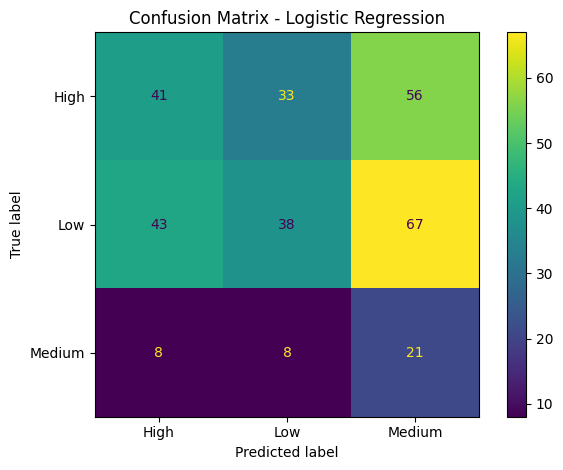

In [30]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic, labels=logistic_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_logistic, display_labels=logistic_model.classes_)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()

## Model 2: Random Forest

In [31]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)

rf_metrics = {
    "model": "Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_rf),
    "macro_f1": f1_score(y_test, y_pred_rf, average="macro")
}

pd.DataFrame([rf_metrics])

,model,accuracy,balanced_accuracy,macro_f1
0,Random Forest,0.542857,0.45738,0.455916


In [32]:
print("Random Forest Results")
print("-" * 40)
print("Accuracy:", round(rf_metrics["accuracy"], 4))
print("Balanced Accuracy:", round(rf_metrics["balanced_accuracy"], 4))
print("Macro F1:", round(rf_metrics["macro_f1"], 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
----------------------------------------
Accuracy: 0.5429
Balanced Accuracy: 0.4574
Macro F1: 0.4559

Classification Report:
              precision    recall  f1-score   support

        High       0.58      0.62      0.60       130
         Low       0.64      0.57      0.60       148
      Medium       0.16      0.19      0.17        37

    accuracy                           0.54       315
   macro avg       0.46      0.46      0.46       315
weighted avg       0.56      0.54      0.55       315



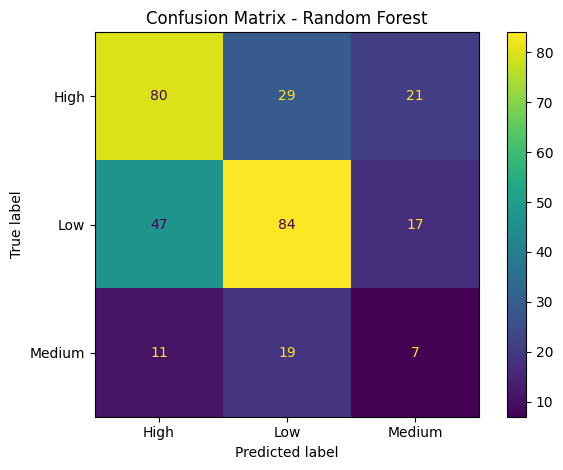

In [33]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=random_forest_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=random_forest_model.classes_)

disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()
plt.show()

## Cross-validation comparison

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro"
}

logistic_cv = cross_validate(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

rf_cv = cross_validate(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

cv_results = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "cv_accuracy_mean": [logistic_cv["test_accuracy"].mean(), rf_cv["test_accuracy"].mean()],
    "cv_balanced_accuracy_mean": [
        logistic_cv["test_balanced_accuracy"].mean(),
        rf_cv["test_balanced_accuracy"].mean()
    ],
    "cv_macro_f1_mean": [logistic_cv["test_macro_f1"].mean(), rf_cv["test_macro_f1"].mean()]
})

cv_results = cv_results.round(4)
cv_results

,model,cv_accuracy_mean,cv_balanced_accuracy_mean,cv_macro_f1_mean
0,Logistic Regression,0.3206,0.4015,0.3171
1,Random Forest,0.5143,0.4591,0.4538


## Feature importance

In [35]:
# extract transformed feature names
ohe = random_forest_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_names = ohe.get_feature_names_out(categorical_features)

all_feature_names = list(numeric_features) + list(encoded_cat_names)

rf_classifier = random_forest_model.named_steps["classifier"]
feature_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance": rf_classifier.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(15)

,feature,importance
0,zone_number,0.615114
1,status_hour,0.298215
7,status_day_Tuesday,0.021399
3,status_day_Monday,0.011749
6,status_day_Thursday,0.011205
2,status_day_Friday,0.009514
8,status_day_Wednesday,0.008547
4,status_day_Saturday,0.006817
9,is_weekend_False,0.006313
10,is_weekend_True,0.006167


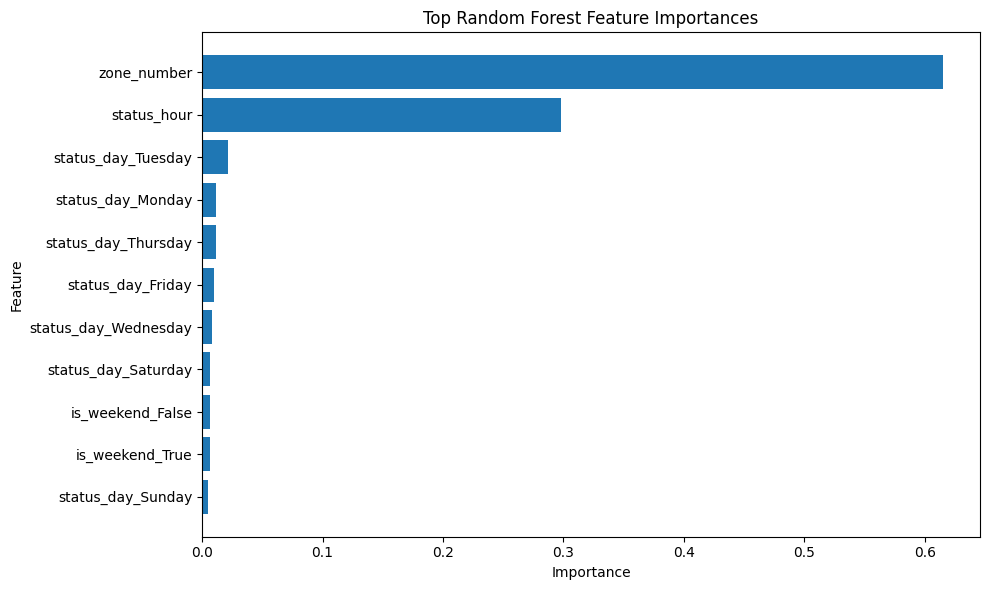

In [36]:
top_features = feature_importance.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## Save modelling outputs

In [37]:
test_results = pd.DataFrame([
    logistic_metrics,
    rf_metrics
]).round(4)

test_results.to_csv(os.path.join(model_dir, "model_test_results.csv"), index=False)
cv_results.to_csv(os.path.join(model_dir, "model_cv_results.csv"), index=False)
feature_importance.to_csv(os.path.join(model_dir, "random_forest_feature_importance.csv"), index=False)

print("Saved files:")
print(os.path.join(model_dir, "model_test_results.csv"))
print(os.path.join(model_dir, "model_cv_results.csv"))
print(os.path.join(model_dir, "random_forest_feature_importance.csv"))

Saved files:
c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\supriya\outputs\model\model_test_results.csv
c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\supriya\outputs\model\model_cv_results.csv
c:\Users\SHARP\MOP-Code\Playground\project-27-smart-parking-demand-prediction\supriya\outputs\model\random_forest_feature_importance.csv
